# 24069723_Data_Science_Project
# "Electricity Consumption Forecasting Using Classical and Machine Learning Time Series Models."

## 1. Import required libraries

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

In [4]:
# Mount the google drive to access the data zip file.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# locating the zip file and accessing it.

import os

zip_path = "/content/drive/MyDrive/individual+household+electric+power+consumption.zip"

# Check if file exists
os.path.exists(zip_path)


True

In [6]:
# Import data

import zipfile

extract_path = "/content/individual+household+electric+power+consumption.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

os.listdir(extract_path)


['household_power_consumption.txt']

In [7]:

data_path = extract_path + "/household_power_consumption.txt"

df = pd.read_csv(
    data_path,
    sep=';',
    na_values='?',
    low_memory=False
)

df.head()


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [8]:
df.shape

(2075259, 9)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), object(2)
memory usage: 142.5+ MB


## 2. Create DateTime index + sort + basic checks

In [10]:
# Combine Date + Time into a single datetime
df["DateTime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%d/%m/%Y %H:%M:%S",
    errors="coerce"
)

In [11]:
# Drop old cols and set index
df = df.drop(columns=["Date", "Time"]).set_index("DateTime")

In [12]:
# Sort index (important for time-series)
df = df.sort_index()

In [13]:
# Quick checks
print("Datetime NA:", df.index.isna().sum())
print("Start:", df.index.min(), "End:", df.index.max())
print("Duplicates:", df.index.duplicated().sum())
df.head()

Datetime NA: 0
Start: 2006-12-16 17:24:00 End: 2010-11-26 21:02:00
Duplicates: 0


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
DateTime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


## 3. Missing values overview

In [14]:
na_counts = df.isna().sum().sort_values(ascending=False)
na_pct = (df.isna().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({"missing_count": na_counts, "missing_pct": na_pct})
missing_summary


,missing_count,missing_pct
Global_active_power,25979,1.251844
Global_reactive_power,25979,1.251844
Voltage,25979,1.251844
Global_intensity,25979,1.251844
Sub_metering_1,25979,1.251844
Sub_metering_2,25979,1.251844
Sub_metering_3,25979,1.251844


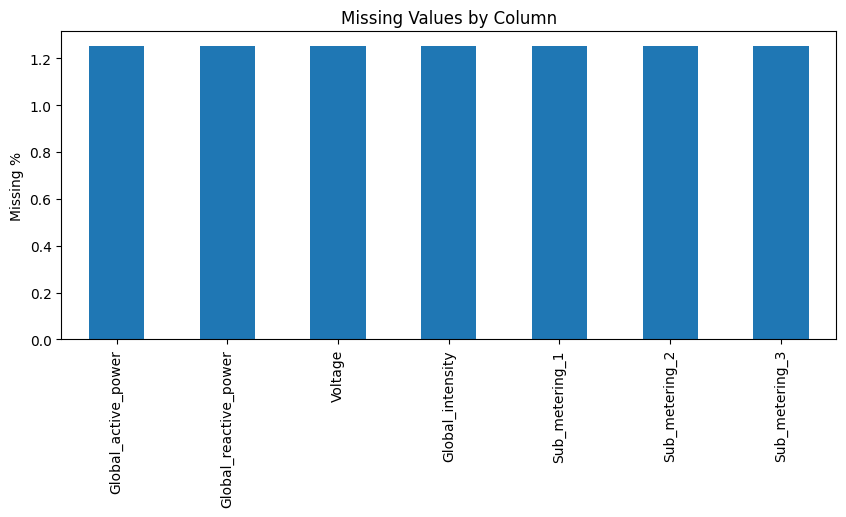

In [15]:
# Plot analysis of missing values.


plt.figure(figsize=(10,4))
missing_summary["missing_pct"].plot(kind="bar")
plt.ylabel("Missing %")
plt.title("Missing Values by Column")
plt.show()


“Approximately 1.25% of observations contained missing values, occurring simultaneously across all sensor variables. This pattern suggests brief interruptions in data acquisition rather than variable-specific errors. Missing values were handled using time-based interpolation, followed by forward and backward filling at dataset boundaries. This approach preserves temporal continuity and avoids distortion of seasonal consumption patterns.”

In [16]:
# Time-based interpolation
df_interp = df.interpolate(method="time")

# Handle edge cases
df_interp = df_interp.ffill().bfill()

# Final check
df_interp.isna().sum()

,0
Global_active_power,0
Global_reactive_power,0
Voltage,0
Global_intensity,0
Sub_metering_1,0
Sub_metering_2,0
Sub_metering_3,0


📌 This preserves:

Temporal continuity

Seasonal patterns

Physical meaning of power signals

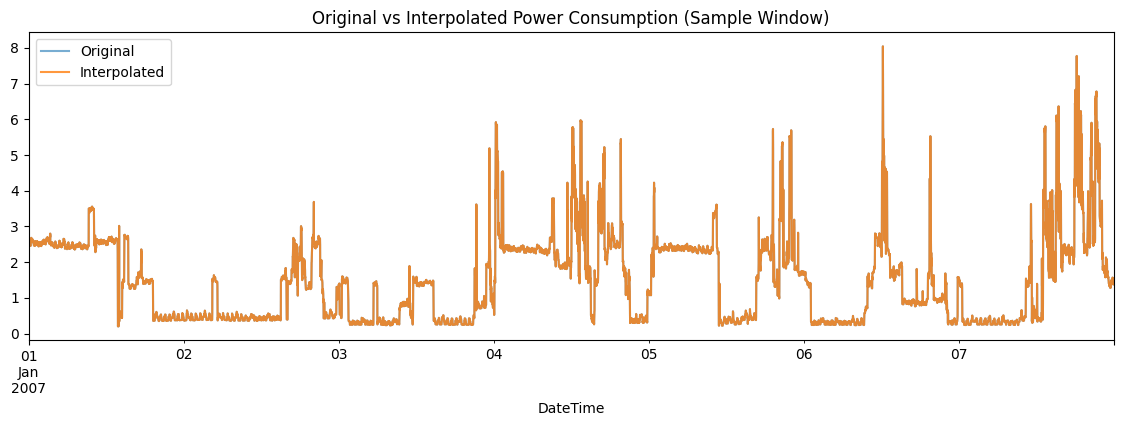

In [17]:
# Compare original vs interpolated for a small window
sample_start = "2007-01-01"
sample_end = "2007-01-07"

plt.figure(figsize=(14,4))
df.loc[sample_start:sample_end, "Global_active_power"].plot(label="Original", alpha=0.6)
df_interp.loc[sample_start:sample_end, "Global_active_power"].plot(label="Interpolated", alpha=0.8)
plt.legend()
plt.title("Original vs Interpolated Power Consumption (Sample Window)")
plt.show()

“A visual comparison between original and interpolated power consumption values over a representative time window confirmed that time-based interpolation preserved the temporal structure of the data. No artificial spikes or discontinuities were introduced, indicating that the interpolation strategy was appropriate for the observed missingness pattern.”

In [18]:
# Resample.

df_hourly = df_interp.resample("H").mean()
df_daily = df_interp.resample("D").mean()

df_hourly.shape, df_daily.shape


/tmp/ipython-input-403729046.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df_interp.resample("H").mean()


((34589, 7), (1442, 7))

In [20]:
# Base Dataset for Modelling.

df_model = df_interp.resample("H").mean()
df_model.head()

/tmp/ipython-input-959382516.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_model = df_interp.resample("H").mean()


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
DateTime,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


## 4. Feature Engineering.

In [21]:
df_model["hour"] = df_model.index.hour
df_model["dayofweek"] = df_model.index.dayofweek
df_model["day"] = df_model.index.day
df_model["month"] = df_model.index.month
df_model["year"] = df_model.index.year
df_model["is_weekend"] = (df_model["dayofweek"] >= 5).astype(int)

In [22]:
df_model.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,hour,dayofweek,day,month,year,is_weekend
DateTime,,,,,,,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111,17,5,16,12,2006,1
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667,18,5,16,12,2006,1
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333,19,5,16,12,2006,1
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333,20,5,16,12,2006,1
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667,21,5,16,12,2006,1


## 5. Lag Features (Critical for Forecasting)

In [23]:
# Target variable
target = "Global_active_power"

# Lag features (hours)
lags = [1, 2, 3, 6, 12, 24]

for lag in lags:
    df_model[f"{target}_lag_{lag}"] = df_model[target].shift(lag)

## 6. Rolling Statistics (Captures Trend & Volatility)

In [24]:
windows = [3, 6, 12, 24]

for w in windows:
    df_model[f"{target}_roll_mean_{w}"] = df_model[target].rolling(w).mean()
    df_model[f"{target}_roll_std_{w}"] = df_model[target].rolling(w).std()

## 7. Drop Initial NaNs (From Lag/Rolling)

In [25]:
df_model.dropna(inplace=True)
df_model.shape

(34565, 27)

## 8. Exploratory Data Analysis (Final EDA)
(A) Distribution of Target

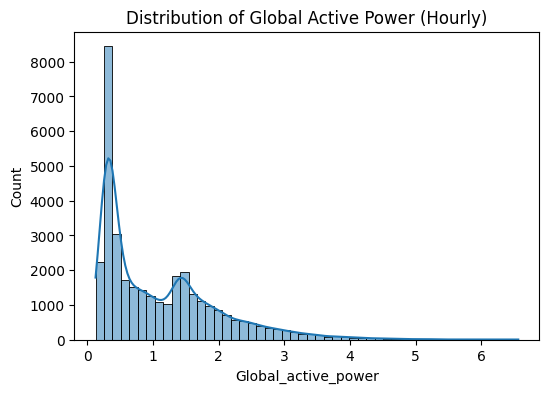

In [26]:
plt.figure(figsize=(6,4))
sns.histplot(df_model[target], bins=50, kde=True)
plt.title("Distribution of Global Active Power (Hourly)")
plt.show()

(B) Correlation Heatmap (Numerical Only)

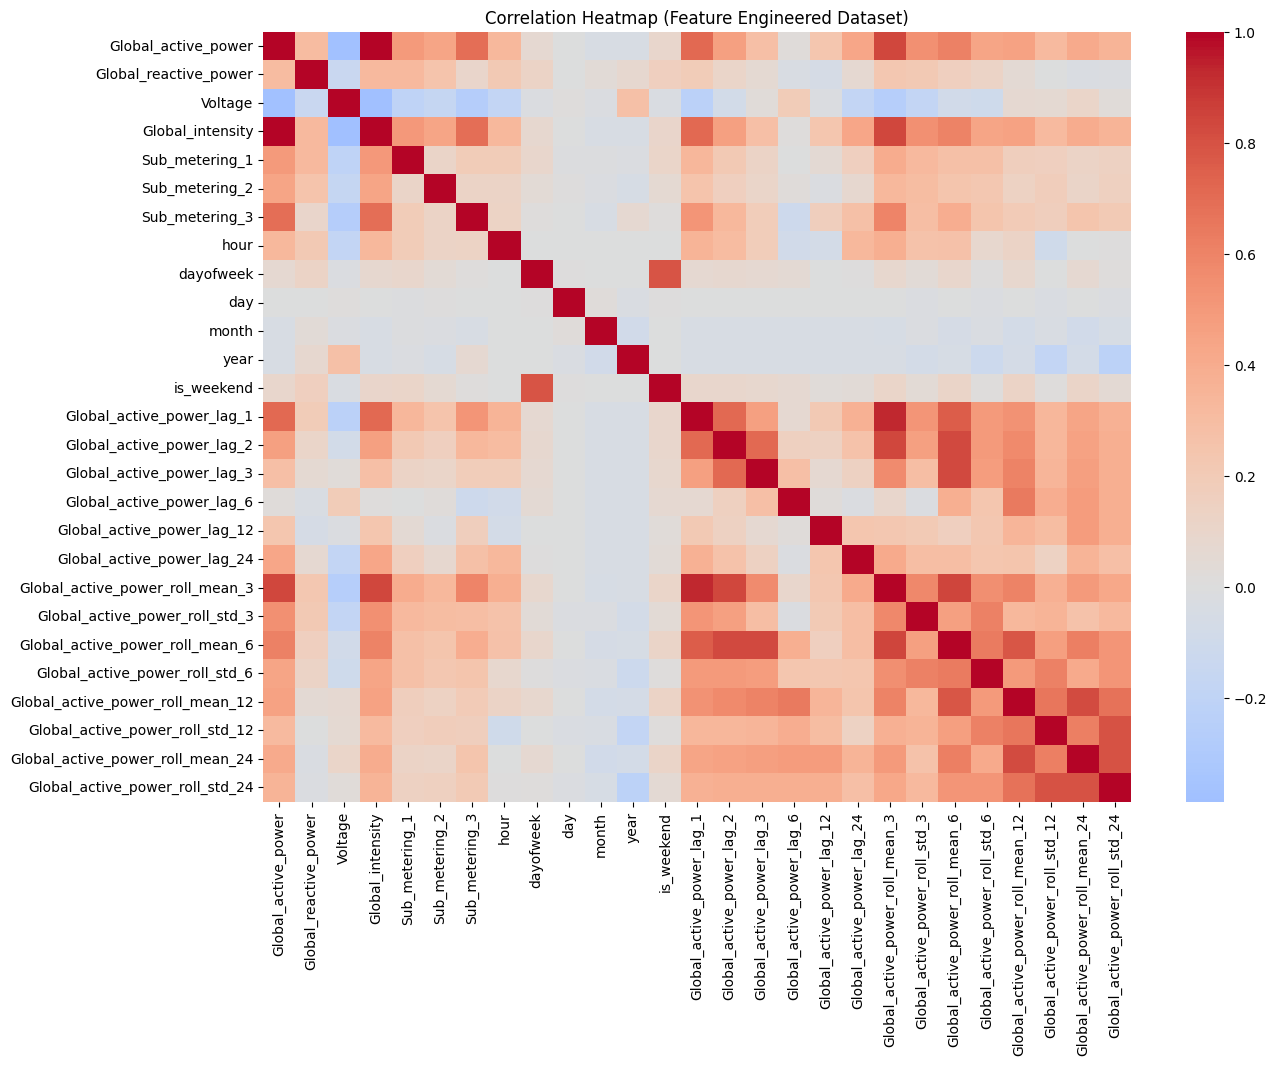

In [27]:
plt.figure(figsize=(14,10))
sns.heatmap(
    df_model.corr(),
    cmap="coolwarm",
    center=0,
    cbar=True
)
plt.title("Correlation Heatmap (Feature Engineered Dataset)")
plt.show()

(C) Focused Correlation with Target

In [28]:
corr_target = (
    df_model.corr()[target]
    .sort_values(ascending=False)
)

corr_target

,Global_active_power
Global_active_power,1.000000
Global_intensity,0.999418
Global_active_power_roll_mean_3,0.837078
Global_active_power_lag_1,0.714388
Sub_metering_3,0.696410
Global_active_power_roll_mean_6,0.611604
Global_active_power_roll_std_3,0.540392
Sub_metering_1,0.496070
Global_active_power_lag_2,0.467212
Global_active_power_roll_mean_12,0.457775


## 9. Multicollinearity Check

In [29]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df_model.drop(columns=[target])
X = X.select_dtypes(include=[np.number])

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif_data.sort_values("VIF", ascending=False)


,feature,VIF
18,Global_active_power_roll_mean_3,40274.478588
10,year,11957.150067
1,Voltage,11947.617049
2,Global_intensity,5081.955820
12,Global_active_power_lag_1,4997.285147
13,Global_active_power_lag_2,4978.428836
20,Global_active_power_roll_mean_6,78.676964
22,Global_active_power_roll_mean_12,54.729848
24,Global_active_power_roll_mean_24,53.622156
25,Global_active_power_roll_std_24,41.705643


"Had a thought of Normalization. But, to avoid data leakage decided to apply scaling after train-test splitting to avoid data leakage."

## 10. Final “Modelling-Ready” Dataset

In [30]:
print("Final shape:", df_model.shape)
print("Missing values:", df_model.isna().sum().sum())
print("Datetime sorted:", df_model.index.is_monotonic_increasing)

Final shape: (34565, 27)
Missing values: 0
Datetime sorted: True



✅ No missing values

✅ Sorted datetime index

✅ Feature engineered

✅ EDA complete

| Stage             | Rows       | Why                   |
| ----------------- | ---------- | --------------------- |
| Raw data          | ~2,075,259 | Minute-level readings |
| Hourly resampled  | ~35,000    | 60 → 1 aggregation    |
| After lag/rolling | 34,565     | Initial rows dropped  |